# Part 1: Data Understanding

## 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from pandas.plotting import scatter_matrix
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1.2 Load Dataset

In [2]:
df = pd.read_csv("wine-clustering.csv")
print("Dataset loaded successfully")


Dataset loaded successfully


## 1.3 Dataset Overview

In [3]:
print("Dataset Shape:")
print(df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(178, 13)

First 5 Rows:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Column Names:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']

Data Types:
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object


## 1.4 Missing Values and Duplicates

In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Total Missing Values:
0

Duplicate Rows:
0


## 1.5 Summary Statistics

In [5]:
print("Summary Statistics:")
display(df.describe())
print("\nInterpretation:")
print("The dataset contains chemical measurements of wines.")
print("PCA can reduce correlated chemical features into fewer principal components.")

Summary Statistics:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



Interpretation:
The dataset contains chemical measurements of wines.
PCA can reduce correlated chemical features into fewer principal components.


# Part 2: EDA

## 2.1 Histograms

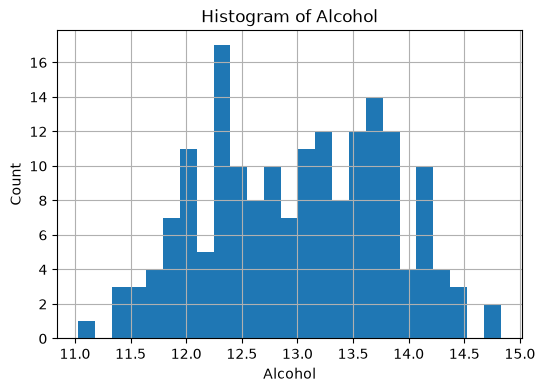

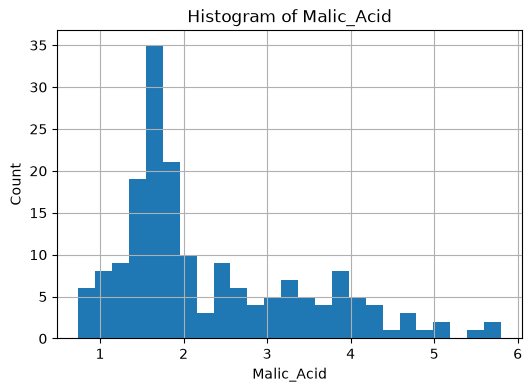

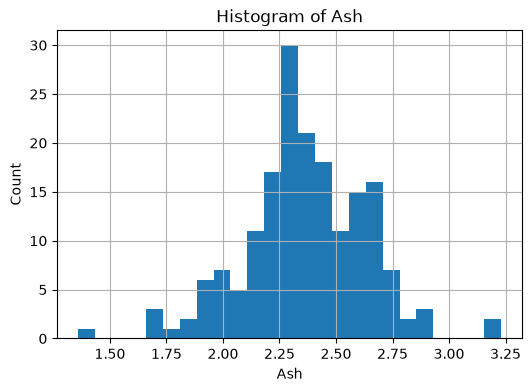

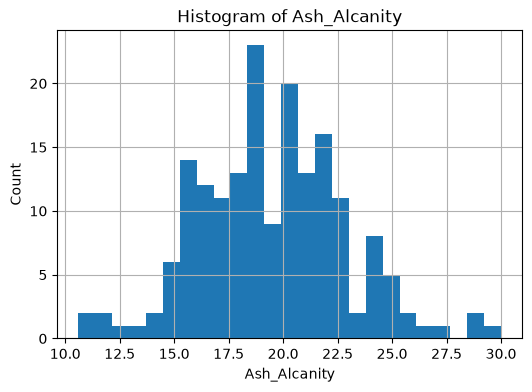

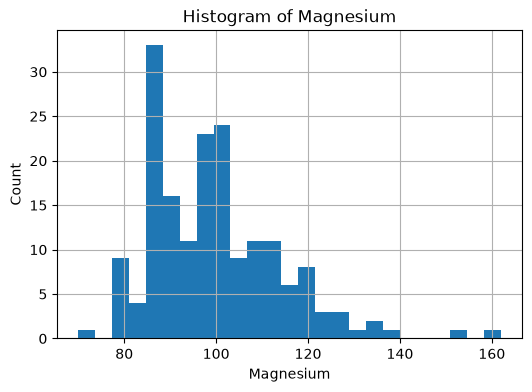

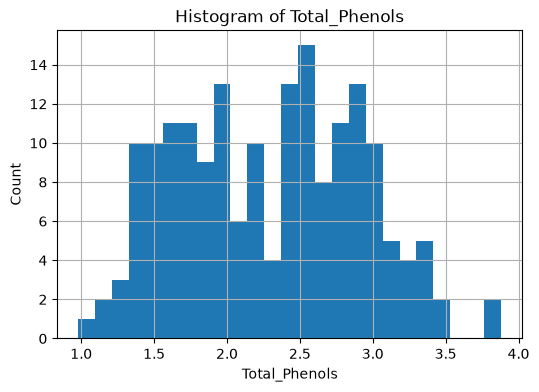

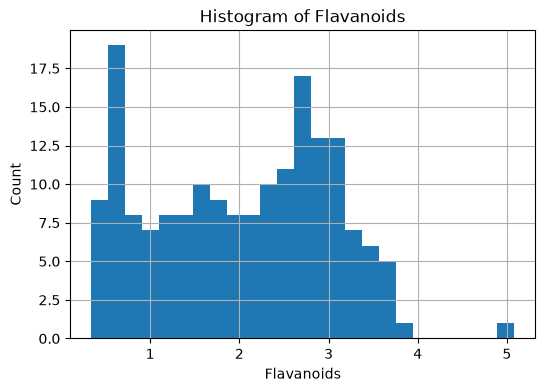

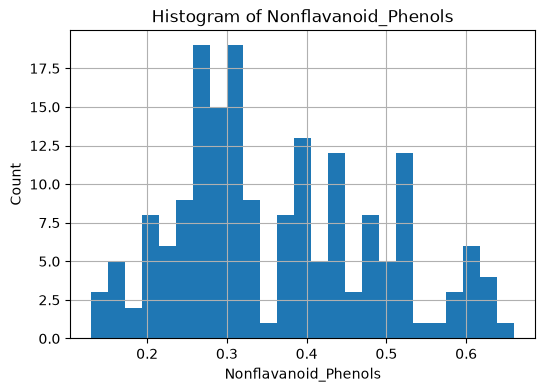

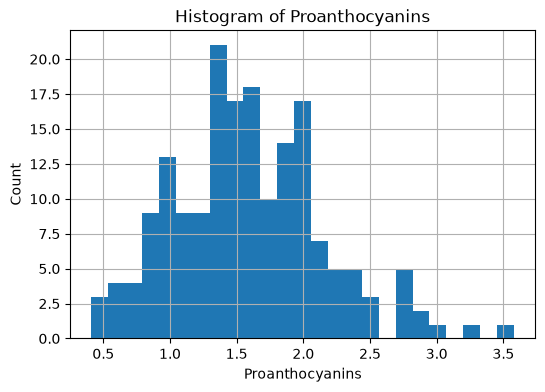

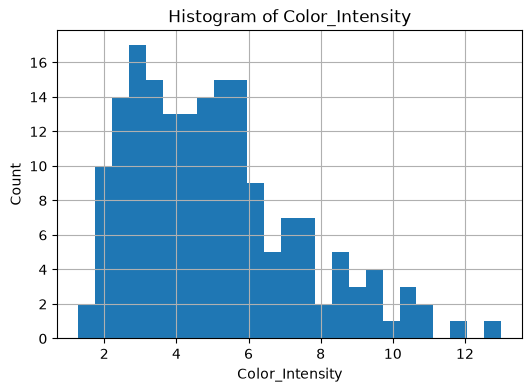

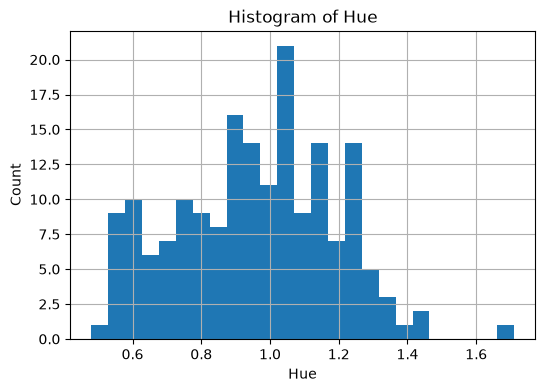

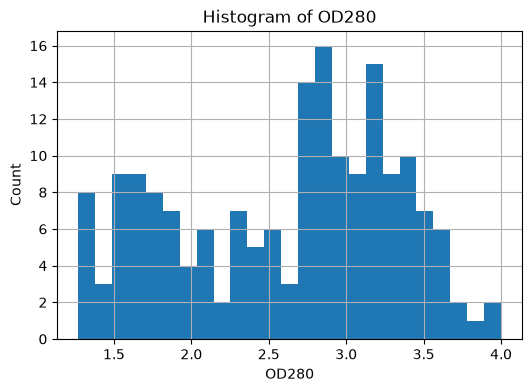

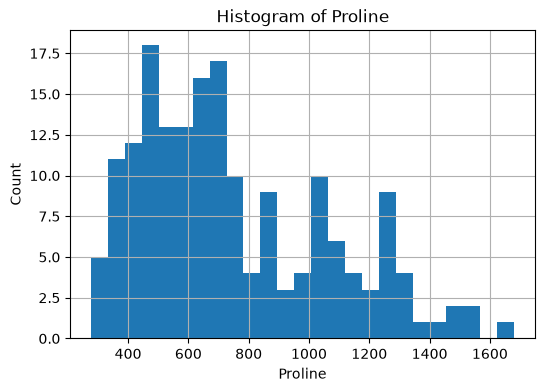

Histograms show the distribution of each feature.


In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=25)
    plt.title("Histogram of " + col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
print("Histograms show the distribution of each feature.")

## 2.2 Boxplots

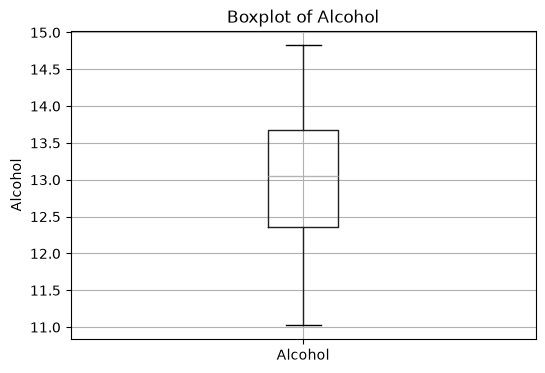

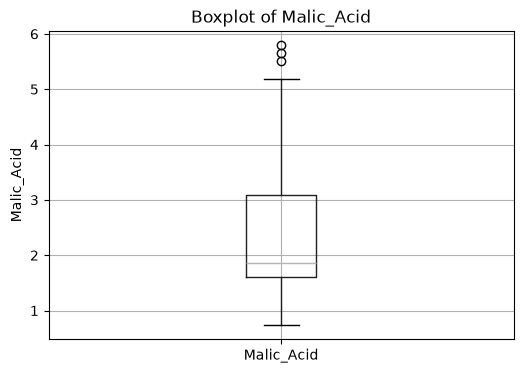

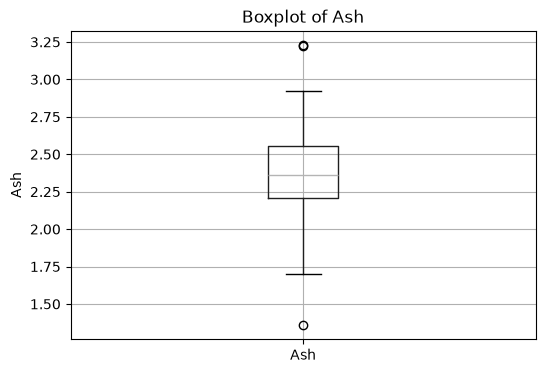

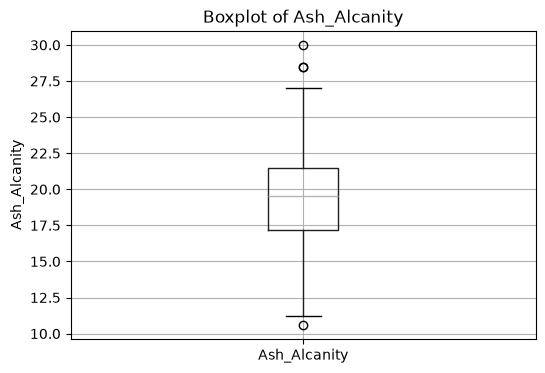

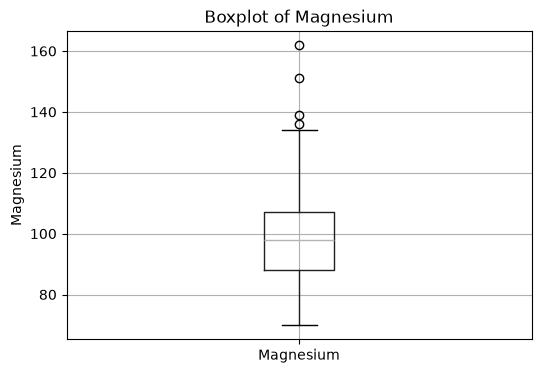

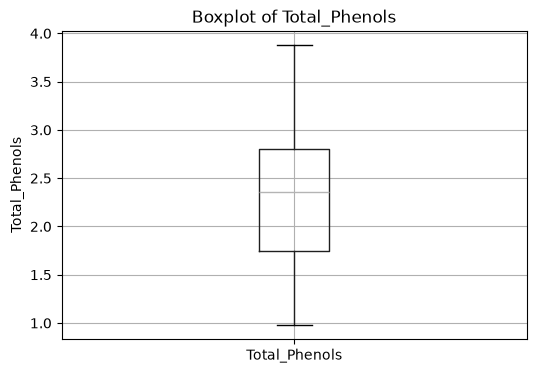

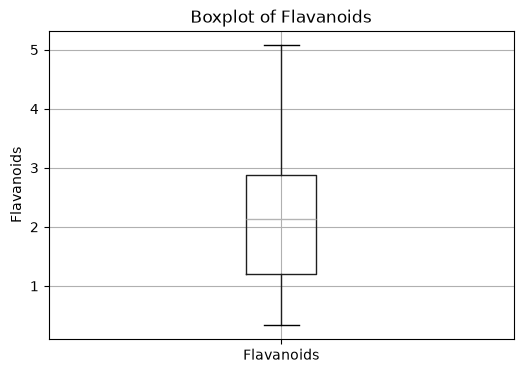

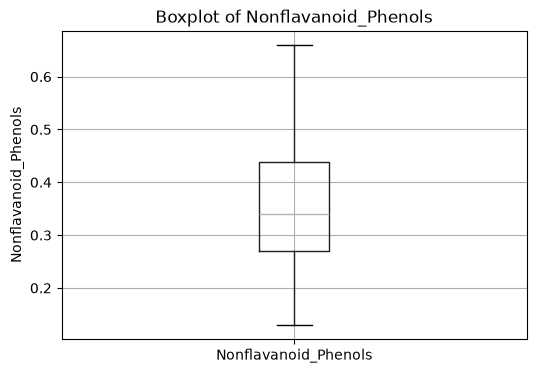

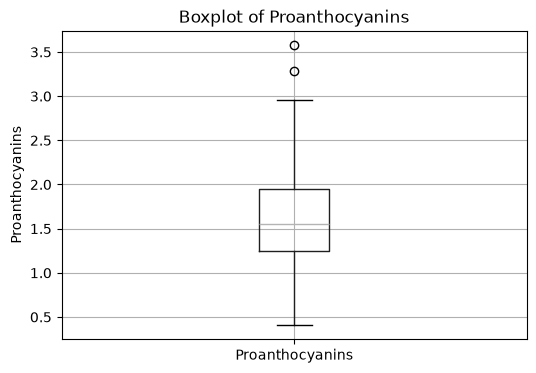

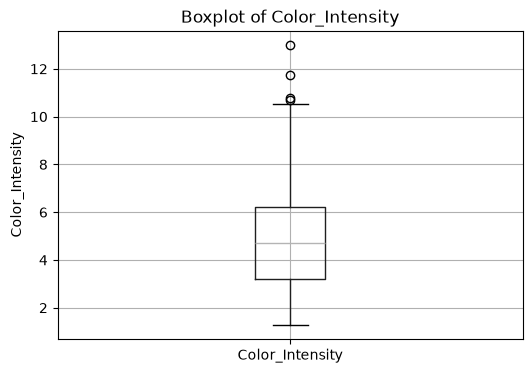

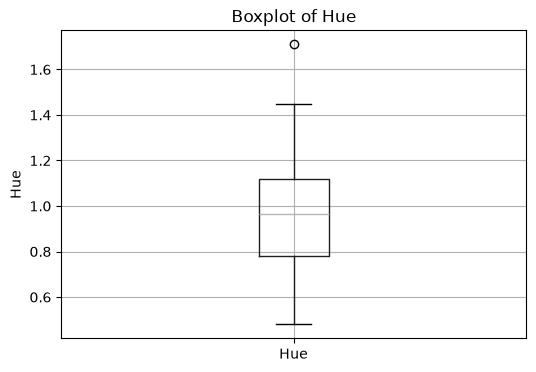

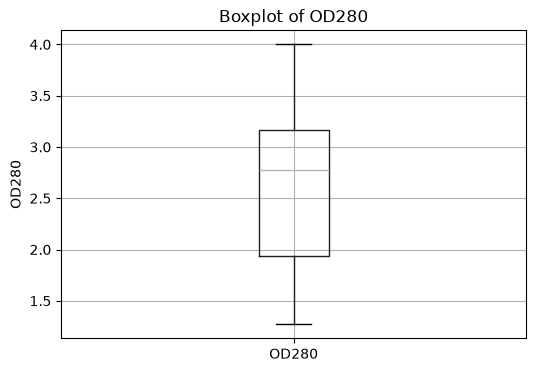

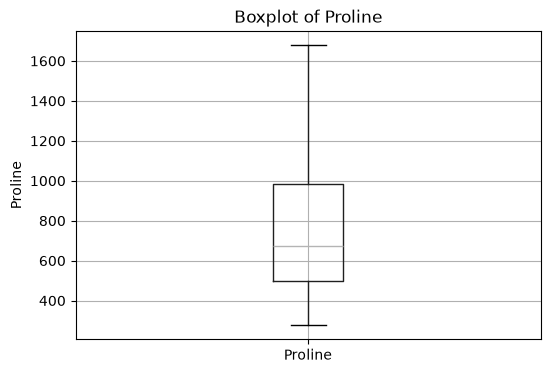

Boxplots help identify outliers and feature spread.


In [7]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title("Boxplot of " + col)
    plt.ylabel(col)
    plt.show()
print("Boxplots help identify outliers and feature spread.")

## 2.3 Correlation Heatmap

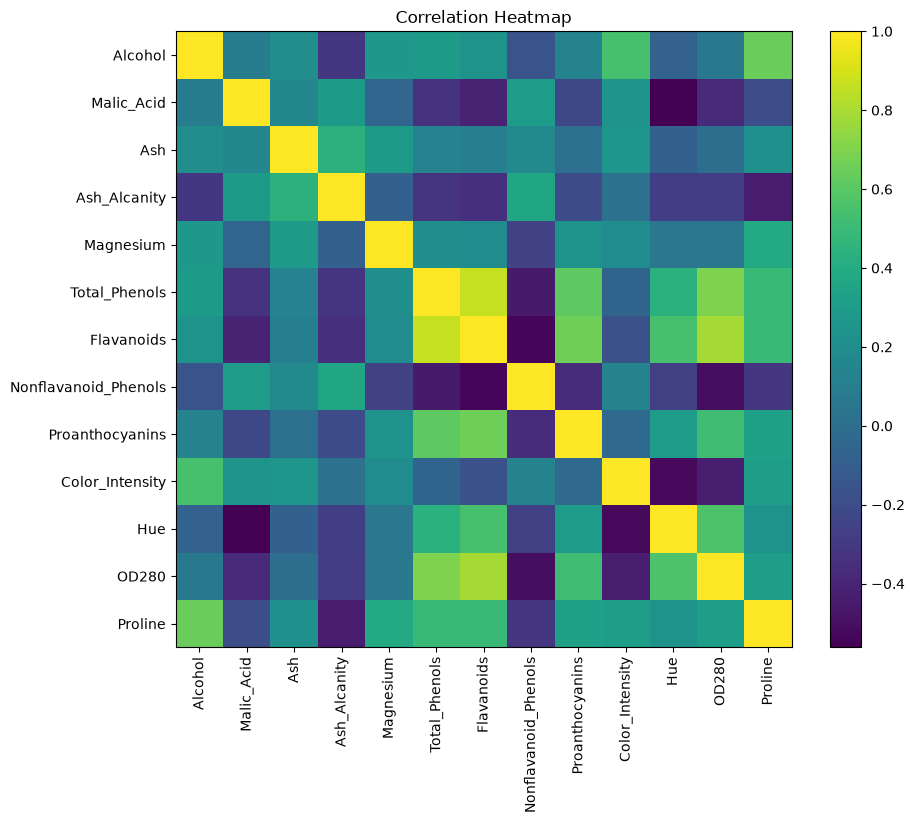

The heatmap shows relationships between features.
Highly correlated features create redundancy, which PCA can reduce.


In [8]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()
print("The heatmap shows relationships between features.")
print("Highly correlated features create redundancy, which PCA can reduce.")

## 2.4 Pair Plot

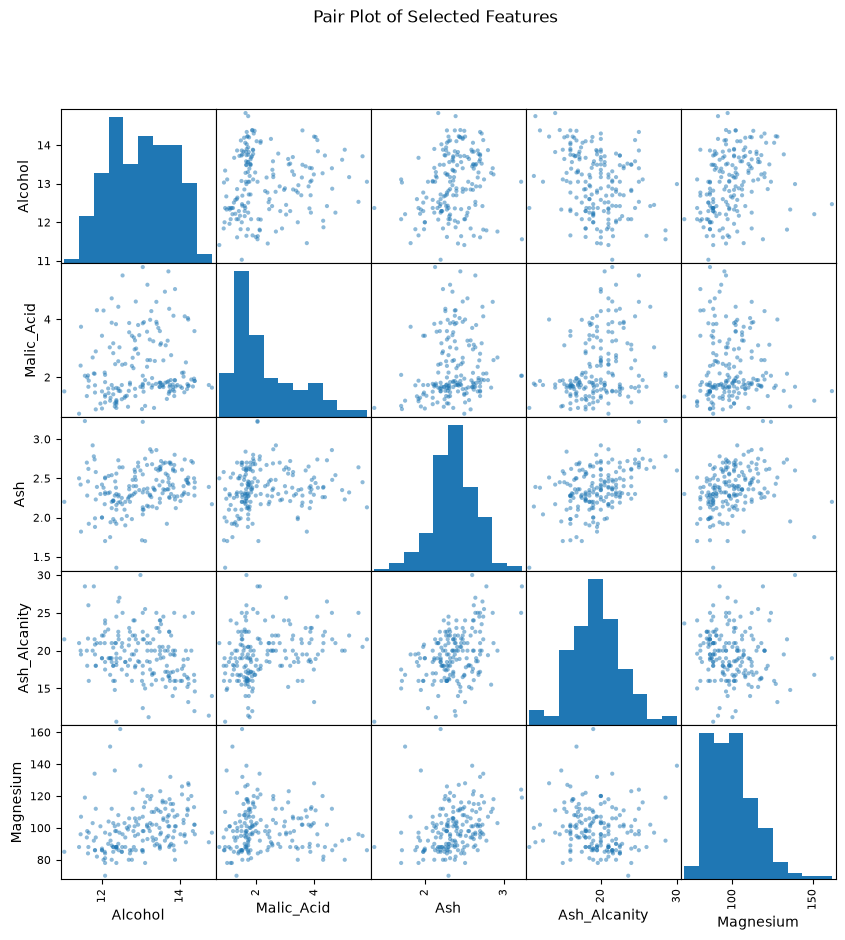

Pair plot shows relationships among selected features.


In [9]:
selected_cols = numeric_cols[:5]
scatter_matrix(df[selected_cols], figsize=(10,10), diagonal="hist")
plt.suptitle("Pair Plot of Selected Features")
plt.show()
print("Pair plot shows relationships among selected features.")

## 2.5 EDA Questions

In [10]:
print("EDA Questions and Answers:")
print("1. Are there missing values? Checked using isnull().sum().")
print("2. Are there duplicates? Checked using duplicated().sum().")
print("3. Are there outliers? Checked using boxplots.")
print("4. Are features correlated? Checked using correlation heatmap.")
print("5. Why PCA? PCA reduces correlated and redundant features.")

EDA Questions and Answers:
1. Are there missing values? Checked using isnull().sum().
2. Are there duplicates? Checked using duplicated().sum().
3. Are there outliers? Checked using boxplots.
4. Are features correlated? Checked using correlation heatmap.
5. Why PCA? PCA reduces correlated and redundant features.


# Part 3: Preprocessing

## 3.1 Remove Duplicates

In [11]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print("Original Shape:", df.shape)
print("Shape After Removing Duplicates:", df_clean.shape)

Original Shape: (178, 13)
Shape After Removing Duplicates: (178, 13)


## 3.2 Handle Missing Values

In [12]:
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print("Missing Values After Treatment:")
print(df_clean.isnull().sum().sum())

Missing Values After Treatment:
0


## 3.3 Standardize Features

In [13]:
X = df_clean.select_dtypes(include=["int64", "float64"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaling Completed")
display(X_scaled_df.head())

Scaling Completed


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 3.4 Why Scaling is Required

In [14]:
print("PCA is affected by feature scale.")
print("Features with large values can dominate PCA.")
print("StandardScaler gives every feature mean 0 and standard deviation 1.")
print("This allows PCA to treat all features fairly.")

PCA is affected by feature scale.
Features with large values can dominate PCA.
StandardScaler gives every feature mean 0 and standard deviation 1.
This allows PCA to treat all features fairly.


# Part 4: Correlation Analysis

## 4.1 Correlation Matrix

In [15]:
correlation_matrix = X.corr()
display(correlation_matrix)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic_Acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Ash_Alcanity,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total_Phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid_Phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
Color_Intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


## 4.2 Highly Correlated Features

In [16]:
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        value = correlation_matrix.iloc[i, j]
        if abs(value) > 0.70:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], value))
high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
display(high_corr_df)

,Feature 1,Feature 2,Correlation
0,Flavanoids,Total_Phenols,0.864564
1,OD280,Flavanoids,0.787194


## 4.3 PCA Benefits

In [17]:
print("PCA Benefits:")
print("PCA reduces correlated features into fewer components.")
print("PCA reduces redundancy.")
print("PCA helps visualize high-dimensional data.")
print("PCA can reduce noise and improve clustering speed.")

PCA Benefits:
PCA reduces correlated features into fewer components.
PCA reduces redundancy.
PCA helps visualize high-dimensional data.
PCA can reduce noise and improve clustering speed.


# Part 5: Apply PCA

## 5.1 Fit PCA

In [18]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
print("PCA Completed")
print("PCA Shape:", X_pca_full.shape)

PCA Completed
PCA Shape: (178, 13)


## 5.2 Eigenvalues

In [19]:
eigenvalues = pca_full.explained_variance_
eigenvalue_df = pd.DataFrame({"Component": range(1, len(eigenvalues) + 1), "Eigenvalue": eigenvalues})
display(eigenvalue_df)

,Component,Eigenvalue
0,1,4.732437
1,2,2.511081
2,3,1.454242
3,4,0.924166
4,5,0.858049
5,6,0.645282
6,7,0.554141
7,8,0.350466
8,9,0.290512
9,10,0.252320


## 5.3 Explained Variance Ratio

In [20]:
explained_variance = pca_full.explained_variance_ratio_
variance_df = pd.DataFrame({"Component": range(1, len(explained_variance) + 1), "Explained Variance Ratio": explained_variance})
display(variance_df)

,Component,Explained Variance Ratio
0,1,0.361988
1,2,0.192075
2,3,0.111236
3,4,0.070690
4,5,0.065633
5,6,0.049358
6,7,0.042387
7,8,0.026807
8,9,0.022222
9,10,0.019300


## 5.4 Cumulative Variance

In [21]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_df = pd.DataFrame({"Component": range(1, len(cumulative_variance) + 1), "Cumulative Variance": cumulative_variance})
display(cumulative_df)

,Component,Cumulative Variance
0,1,0.361988
1,2,0.554063
2,3,0.665300
3,4,0.735990
4,5,0.801623
5,6,0.850981
6,7,0.893368
7,8,0.920175
8,9,0.942397
9,10,0.961697


## 5.5 PCA Interpretation

In [22]:
print("The first principal component captures the highest variance.")
print("Explained variance ratio shows how much information each component keeps.")
print("Cumulative variance helps decide how many components to keep.")

The first principal component captures the highest variance.
Explained variance ratio shows how much information each component keeps.
Cumulative variance helps decide how many components to keep.


# Part 6: Choosing Components

## 6.1 Scree Plot

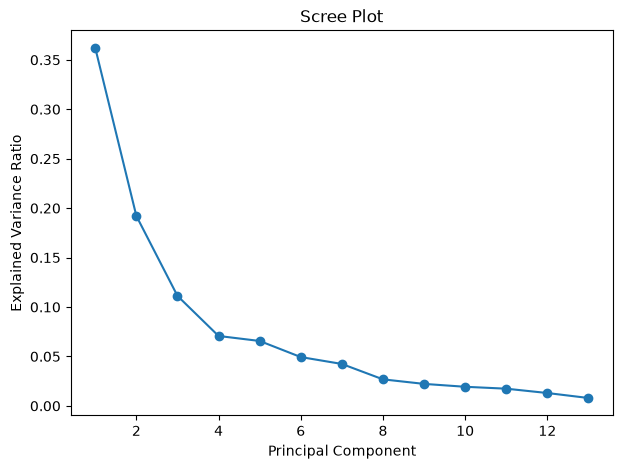

In [23]:
components = range(1, len(explained_variance) + 1)
plt.figure(figsize=(7,5))
plt.plot(components, explained_variance, marker="o")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

## 6.2 Cumulative Explained Variance Plot

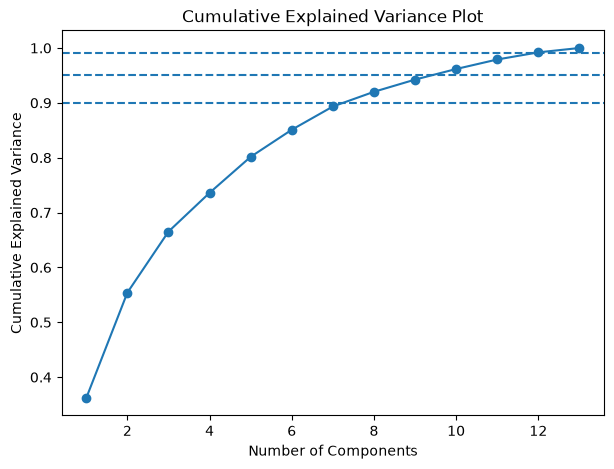

In [24]:
plt.figure(figsize=(7,5))
plt.plot(components, cumulative_variance, marker="o")
plt.axhline(y=0.90, linestyle="--")
plt.axhline(y=0.95, linestyle="--")
plt.axhline(y=0.99, linestyle="--")
plt.title("Cumulative Explained Variance Plot")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

## 6.3 Components for 90%, 95%, and 99% Variance

In [25]:
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print("Components needed for 90% variance:", components_90)
print("Components needed for 95% variance:", components_95)
print("Components needed for 99% variance:", components_99)

Components needed for 90% variance: 8
Components needed for 95% variance: 10
Components needed for 99% variance: 12


# Part 7: Visualization

## 7.1 2D PCA

In [26]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca_2d_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
display(pca_2d_df.head())

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


## 7.2 Visualize 2D PCA

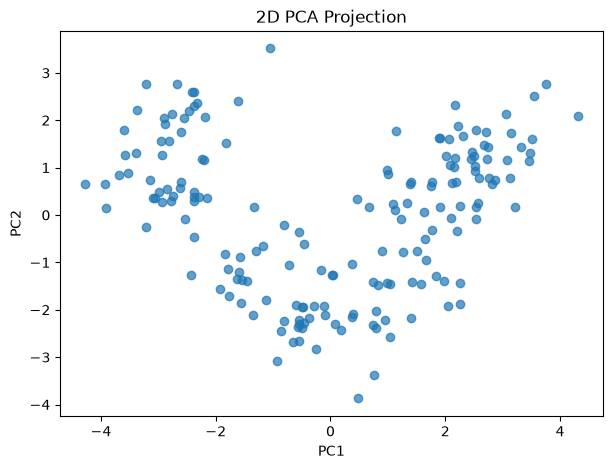

In [27]:
plt.figure(figsize=(7,5))
plt.scatter(pca_2d_df["PC1"], pca_2d_df["PC2"], alpha=0.7)
plt.title("2D PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 7.3 3D PCA

In [28]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
pca_3d_df = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
display(pca_3d_df.head())

,PC1,PC2,PC3
0,3.316751,1.443463,-0.165739
1,2.209465,-0.333393,-2.026457
2,2.516740,1.031151,0.982819
3,3.757066,2.756372,-0.176192
4,1.008908,0.869831,2.026688


## 7.4 Visualize 3D PCA

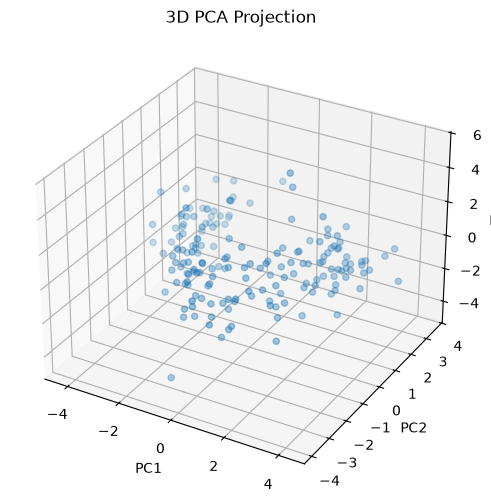

In [29]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_3d_df["PC1"], pca_3d_df["PC2"], pca_3d_df["PC3"], alpha=0.7)
ax.set_title("3D PCA Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

## 7.5 Visualization Interpretation

In [30]:
print("2D and 3D PCA plots help visualize high-dimensional wine data.")
print("If points form groups, it may indicate natural clusters.")
print("If points overlap, wines may have similar chemical profiles.")

2D and 3D PCA plots help visualize high-dimensional wine data.
If points form groups, it may indicate natural clusters.
If points overlap, wines may have similar chemical profiles.


# Part 8: Feature Contribution

## 8.1 PCA Loadings

In [31]:
loadings = pd.DataFrame(pca_2d.components_.T, columns=["PC1", "PC2"], index=X.columns)
display(loadings)

,PC1,PC2
Alcohol,0.144329,0.483652
Malic_Acid,-0.245188,0.224931
Ash,-0.002051,0.316069
Ash_Alcanity,-0.239320,-0.010591
Magnesium,0.141992,0.299634
Total_Phenols,0.394661,0.065040
Flavanoids,0.422934,-0.003360
Nonflavanoid_Phenols,-0.298533,0.028779
Proanthocyanins,0.313429,0.039302
Color_Intensity,-0.088617,0.529996


## 8.2 Most Influential Features for PC1

In [32]:
pc1_features = loadings["PC1"].abs().sort_values(ascending=False)
display(pc1_features.head(5))

Flavanoids              0.422934
Total_Phenols           0.394661
OD280                   0.376167
Proanthocyanins         0.313429
Nonflavanoid_Phenols    0.298533
Name: PC1, dtype: float64

## 8.3 Most Influential Features for PC2

In [33]:
pc2_features = loadings["PC2"].abs().sort_values(ascending=False)
display(pc2_features.head(5))

Color_Intensity    0.529996
Alcohol            0.483652
Proline            0.364903
Ash                0.316069
Magnesium          0.299634
Name: PC2, dtype: float64

## 8.4 Least Influential Features

In [34]:
overall_contribution = loadings.abs().sum(axis=1).sort_values()
display(overall_contribution.head(5))
print("Larger absolute loading means higher feature contribution.")

Ash_Alcanity            0.249911
Ash                     0.318120
Nonflavanoid_Phenols    0.327313
Proanthocyanins         0.352731
Flavanoids              0.426294
dtype: float64

Larger absolute loading means higher feature contribution.


# Part 9: PCA + KMeans

## 9.1 KMeans Before PCA

In [35]:
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
start_time = time.time()
original_labels = kmeans_original.fit_predict(X_scaled)
original_time = time.time() - start_time
original_inertia = kmeans_original.inertia_
original_silhouette = silhouette_score(X_scaled, original_labels)
print("Inertia:", original_inertia)
print("Silhouette Score:", original_silhouette)
print("Training Time:", original_time)

Inertia: 1277.928488844642
Silhouette Score: 0.2848589191898987
Training Time: 1.7726681232452393


## 9.2 KMeans After PCA

In [36]:
pca_for_kmeans = PCA(n_components=components_95)
X_pca_kmeans = pca_for_kmeans.fit_transform(X_scaled)
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
start_time = time.time()
pca_labels = kmeans_pca.fit_predict(X_pca_kmeans)
pca_time = time.time() - start_time
pca_inertia = kmeans_pca.inertia_
pca_silhouette = silhouette_score(X_pca_kmeans, pca_labels)
print("Inertia:", pca_inertia)
print("Silhouette Score:", pca_silhouette)
print("Training Time:", pca_time)

Inertia: 1189.6391379398008
Silhouette Score: 0.29867482943692886
Training Time: 0.023209810256958008


## 9.3 Compare KMeans Before and After PCA

In [37]:
comparison_table = pd.DataFrame({
    "Model": ["KMeans Before PCA", "KMeans After PCA"],
    "Inertia": [original_inertia, pca_inertia],
    "Silhouette Score": [original_silhouette, pca_silhouette],
    "Training Time": [original_time, pca_time]
})
display(comparison_table)

,Model,Inertia,Silhouette Score,Training Time
0,KMeans Before PCA,1277.928489,0.284859,1.772668
1,KMeans After PCA,1189.639138,0.298675,0.023210


## 9.4 Visualize PCA Clusters

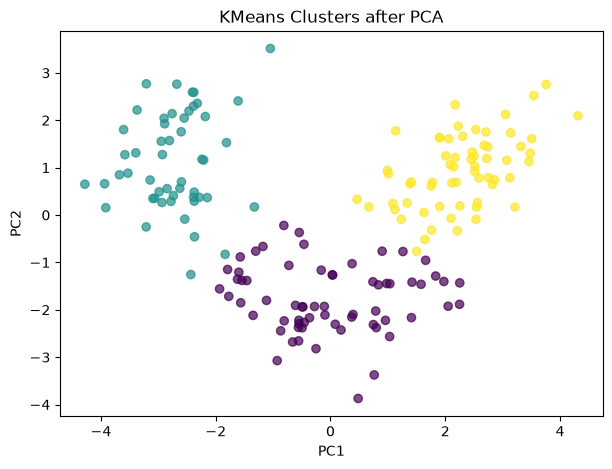

PCA may reduce training time and remove redundant information before clustering.


In [38]:
pca_2d_df["Cluster"] = pca_labels
plt.figure(figsize=(7,5))
plt.scatter(pca_2d_df["PC1"], pca_2d_df["PC2"], c=pca_2d_df["Cluster"], alpha=0.7)
plt.title("KMeans Clusters after PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
print("PCA may reduce training time and remove redundant information before clustering.")

# Part 10: Theory

In [39]:
print("PCA Theory Questions and Answers:")
print("1. PCA transforms original features into principal components.")
print("2. Scaling is required because PCA is affected by feature magnitude.")
print("3. Eigenvectors show principal component directions.")
print("4. Eigenvalues show how much variance each component captures.")
print("5. Explained variance shows how much information is retained.")
print("6. PCA can reduce noise by removing low-variance components.")
print("7. PCA is unsupervised because it does not use a target variable.")
print("8. PCA can make interpretation harder because components are combinations of original features.")
print("9. PCA is useful when features are correlated.")
print("10. PCA can improve clustering by reducing redundancy.")

PCA Theory Questions and Answers:
1. PCA transforms original features into principal components.
2. Scaling is required because PCA is affected by feature magnitude.
3. Eigenvectors show principal component directions.
4. Eigenvalues show how much variance each component captures.
5. Explained variance shows how much information is retained.
6. PCA can reduce noise by removing low-variance components.
7. PCA is unsupervised because it does not use a target variable.
8. PCA can make interpretation harder because components are combinations of original features.
9. PCA is useful when features are correlated.
10. PCA can improve clustering by reducing redundancy.


# Final Conclusion

This notebook completed PCA analysis on the Wine dataset.

The workflow included data understanding, EDA, preprocessing, correlation analysis, PCA, component selection, visualization, feature contribution, PCA with KMeans, and theory answers.

PCA helped reduce dimensionality, preserve important variance, visualize wine data, and compare clustering before and after dimensionality reduction.
